# INITIAL IMPORT

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
def parse_state_taxi(env, state):
    taxi_row, taxi_col, passenger_location, destination = env.unwrapped.decode(state)
    # print((taxi_row, taxi_col))
    return (taxi_row, taxi_col)

In [3]:
import os
import numpy as np
import gymnasium as gym
from src.config import Configuration


CONFIG = Configuration(
    n_training_episodes = 20_000,
    learning_rate = 0.7,
    n_eval_episodes = 1000,
    # gym_id = "Taxi-v3",
    # gym_id = "MiniGrid-DoorKey-5x5-v0", 
    rm_file= "rm_taxi_2p.txt",
    # rm_file= "rm_taxi_v2.txt",
    max_steps = 1000,
    gamma = 0.90,
    max_epsilon = 1.0,
    min_epsilon = 0.05,
    decay_rate = 0.0001,
    use_rm = True, 
    use_crm = True, 
    parse_state = None, 
    # parse_state = parse_state_taxi,
    skip_first_rm_state = False,  # Set to True to step RM immediately after reset
    dynamic_qtable = True,
)

# LOAD ENV

In [4]:
from src.envs import MultiTaxiEnv

env = MultiTaxiEnv(grid_size=5, num_passengers=2, render_mode='rgb_array')

state_space = env.observation_space.n
print("There are ", state_space, " possible states")
action_space = env.action_space.n
print("There are ", action_space, " possible actions")

state, _ = env.reset()
# Returns a tuple: (taxi_row, taxi_col, passenger_location, destination)
print(env.unwrapped.decode(state))

There are  10000  possible states
There are  6  possible actions
[np.int64(4), np.int64(1), np.int64(0), np.int64(3), np.int64(2), np.int64(0)]


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

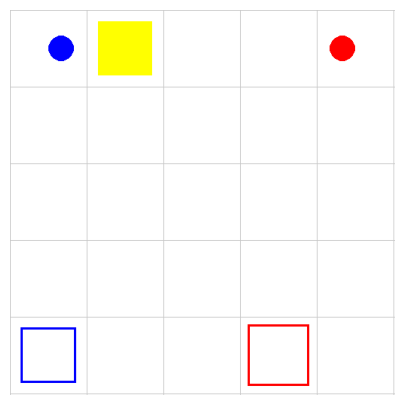

In [5]:
import matplotlib.pyplot as plt
state, _ = env.reset()

env.render()

# 2. Get the single frame
img = env.render()

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis('off')

T (Yellow): Empty Taxi

X (Green): Taxi carrying a passenger

P (Blue): Passenger waiting for pickup

D (Magenta): A passenger's destination location

# DEFINE Q-LEARNING

In [6]:
from src.models import RewardMachine
from src.envs import get_propositions_multi_taxi

get_propositions_fn = get_propositions_multi_taxi

In [7]:
from src.models import QTable

In [8]:
from src.models import train_qtable

In [9]:
from src.models import evaluate_agent

# Generate and train

In [10]:
rm = RewardMachine(CONFIG, CONFIG.rm_file)
rm.states

{0: {(1, ('p1',), 5.0), (2, ('p2',), 5.0), (3, ('p1', 'p2'), 10.0)},
 1: {(0, ('!p1',), -5.0), (3, ('p1', 'p2'), 5.0), (4, ('d1',), 20.0)},
 2: {(0, ('!p2',), -5.0), (3, ('p1', 'p2'), 5.0), (5, ('d2',), 20.0)},
 3: {(0, ('!p1', '!p2'), -10.0),
  (1, ('p1', '!p2'), -5.0),
  (2, ('!p1', 'p2'), -5.0),
  (6, ('d1', 'p2'), 20.0),
  (7, ('p1', 'd2'), 20.0),
  (8, ('d1', 'd2'), 40.0)},
 4: {(1, ('p1',), -5.0), (6, ('d1', 'p2'), 5.0)},
 5: {(2, ('p2',), -5.0), (7, ('p1', 'd2'), 5.0)},
 6: {(3, ('p1', 'p2'), -5.0),
  (4, ('d1', '!p2'), -5.0),
  (8, ('d1', 'd2'), 20.0)},
 7: {(3, ('p1', 'p2'), -5.0),
  (5, ('!p1', 'd2'), -5.0),
  (8, ('d1', 'd2'), 20.0)}}

In [11]:
events = get_propositions_fn(env, state)
# events = get_propositions_doorkey(env, state)

rm.step(events)

(0, -1, False)

In [12]:
qt = QTable(CONFIG, env, rm_file=CONFIG.rm_file if CONFIG.use_rm else None, dynamic=CONFIG.dynamic_qtable)
qt = train_qtable(
    CONFIG, 
    qt,  
    get_propositions_fn, 
    env,
)

The QTable is dynamic


100%|██████████| 20000/20000 [06:24<00:00, 52.06it/s]


In [13]:
mean_reward, std_reward = evaluate_agent(CONFIG, qt, get_propositions_fn, env)
print(f"Mean_reward={mean_reward:.2f} +/- {std_reward:.2f}")

100%|██████████| 1000/1000 [00:03<00:00, 278.06it/s]

Mean_reward=8461.12 +/- 3167.05


In [14]:
keys = sorted(qt._storage._table.keys())
print(f"Total Q-table entries: {len(keys)}")

Total Q-table entries: 76276


In [15]:
for key in keys:
    print(f"State: {key[0]}, RM: {key[1]}, Values: [{','.join(f'{i:.4f}' for i in qt._storage._table[key])}]")


State: 0, RM: 0, Values: [0.0000,0.0000,0.0000,0.0000,0.0000,0.0000]
State: 0, RM: 1, Values: [61.6211,69.5789,61.6211,69.5789,78.4211,69.5789]
State: 0, RM: 2, Values: [61.6210,69.5789,61.6211,69.5783,78.4211,69.5789]
State: 0, RM: 3, Values: [61.6189,69.5789,61.6210,69.5789,78.4211,69.5789]
State: 0, RM: 4, Values: [61.6211,69.5789,61.6211,69.5789,78.4211,69.5789]
State: 0, RM: 5, Values: [0.0000,0.0000,0.0000,0.0000,0.0000,0.0000]
State: 0, RM: 6, Values: [61.6211,69.5789,61.6211,69.5789,78.4211,69.5789]
State: 0, RM: 7, Values: [61.6211,69.5789,61.6211,69.5789,78.4211,69.5789]
State: 0, RM: 8, Values: [61.6211,69.5789,61.6211,69.5789,78.4211,69.5789]
State: 0, RM: 9, Values: [61.6211,69.5789,61.6211,69.5789,78.4211,69.5789]
State: 0, RM: 10, Values: [0.0000,0.0000,0.0000,0.0000,0.0000,0.0000]
State: 0, RM: 11, Values: [61.6211,69.5789,61.6211,69.5789,78.4211,69.5789]
State: 0, RM: 12, Values: [61.6211,69.5789,61.6211,69.5789,78.4211,69.5789]
State: 0, RM: 14, Values: [61.6211,69.57

# Record video

In [16]:
from src.utils import record_video

# record_video(CONFIG, qt, env, get_propositions_fn, video_name=f"{CONFIG.rm_file}.gif")

# Bench mark

In [17]:

variants = [
    {
        "label": "No RM / No CRM", 
        "use_rm": False, 
        "use_crm": False, 
        'skip_first_rm_state': False, 
        'rm_file': None,
        'parse_state': None
    },
    {
        "label": "RM / No CRM", 
        "use_rm": True, 
        "use_crm": False, 
        'skip_first_rm_state': False, 
        'rm_file': 'rm_taxi_2p.txt',
        'parse_state': None
    },
    {
        "label": "RM / CRM", 
        "use_rm": True, 
        "use_crm": True, 
        'skip_first_rm_state': False, 
        'rm_file': 'rm_taxi_2p.txt',
        'parse_state': None
    },
    # {
    #     "label": "RM / No CRM NEW", 
    #     "use_rm": True, 
    #     "use_crm": False, 
    #     'skip_first_rm_state': True, 
    #     'rm_file': 'rm_taxi_v2.txt',
    #     # 'parse_state': None
    #     'parse_state': parse_state_taxi
    # },
    # {
    #     "label": "RM / CRM NEW", 
    #     "use_rm": True, 
    #     "use_crm": True, 
    #     'skip_first_rm_state': True, 
    #     'rm_file': 'rm_taxi_v2.txt',
    #     # 'parse_state': None
    #     'parse_state': parse_state_taxi
    # },
]

In [18]:
import numpy as np
from typing import Callable
import matplotlib.pyplot as plt
from tqdm import tqdm

from src.config import Configuration
from src.models import QTable, evaluate_agent


def train_qtable_with_progress(config: Configuration, eval_every: int = 50):
    """Train and periodically evaluate to track learning evolution."""
    # env = gym.make(config.gym_id, render_mode="rgb_array")
    qtable = QTable(config, env, rm_file="rm_taxi.txt" if config.use_rm else None)

    iterations = []
    eval_means = []
    eval_stds = []

    for episode in tqdm(range(config.n_training_episodes), desc=f"RM={config.use_rm}, CRM={config.use_crm}"):
        epsilon = config.min_epsilon + (config.max_epsilon - config.min_epsilon) * np.exp(-config.decay_rate * episode)
        state, _ = env.reset()
        qtable.reset_rm()

        terminated, truncated = False, False
        if config.skip_first_rm_state:
            events = get_propositions_fn(env, state)
            qtable.step_rm(events)
        state = config.parse_state(env, state) if config.parse_state else state
        
        for _ in range(config.max_steps):
            action = qtable.epsilon_greedy_policy(state, epsilon, env)
            new_state, env_reward, terminated, truncated, _ = env.step(action)

            new_state_parse = config.parse_state(env, new_state) if config.parse_state else new_state
            rm_done = qtable.update(
                state,
                action,
                env_reward,
                new_state,
                new_state_parse,
                config.gamma,
                config.learning_rate,
                env,
                use_crm=config.use_crm,
                get_propositions=get_propositions_fn,
                skip_first_rm_state=config.skip_first_rm_state
            )

            if terminated or truncated or rm_done:
                break

            state = new_state

        if (episode + 1) % eval_every == 0 or episode == 0:
            mean_reward, std_reward = evaluate_agent(config, qtable, get_propositions_fn, env)
            iterations.append(episode + 1)
            eval_means.append(mean_reward)
            eval_stds.append(std_reward)

    env.close()
    return qtable, np.array(iterations), np.array(eval_means), np.array(eval_stds)


def convergence_iteration(iterations, values, smooth_window=3, plateau_ratio=0.95, patience=3):
    """Estimate convergence as first iteration that reaches and maintains near-plateau performance."""
    if len(values) == 0:
        return None

    if len(values) < smooth_window:
        smoothed = values
        smooth_iters = iterations
    else:
        kernel = np.ones(smooth_window) / smooth_window
        smoothed = np.convolve(values, kernel, mode="valid")
        smooth_iters = iterations[smooth_window - 1:]

    best = np.max(smoothed)
    threshold = best - (1.0 - plateau_ratio) * max(1.0, abs(best))

    if len(smoothed) < patience:
        return int(smooth_iters[np.argmax(smoothed)])

    for i in range(len(smoothed) - patience + 1):
        if np.all(smoothed[i : i + patience] >= threshold):
            return int(smooth_iters[i])

    return int(smooth_iters[np.argmax(smoothed)])


# Shared benchmark settings
base_kwargs = dict(
    n_training_episodes=20_000,
    learning_rate=0.7,
    n_eval_episodes=200,
    gym_id="Taxi-v3",
    max_steps=1000,
    gamma = 0.90,
    max_epsilon = 1.0,
    min_epsilon = 0.05,
    decay_rate = 0.0001,
)


results = {}

for variant in variants:
    cfg = Configuration(
        **base_kwargs,
        use_rm=variant["use_rm"],
        use_crm=variant["use_crm"],
        skip_first_rm_state=variant["skip_first_rm_state"],
        rm_file=variant["rm_file"],
        parse_state=variant['parse_state']
    )

    _, iters, means, stds = train_qtable_with_progress(cfg, eval_every=200)
    conv_it = convergence_iteration(iters, means, smooth_window=3, plateau_ratio=0.95, patience=3)

    results[variant["label"]] = {
        "iterations": iters,
        "mean_rewards": means,
        "std_rewards": stds,
        "convergence_iteration": conv_it,
    }


The QTable is dynamic


RM=False, CRM=False:   0%|          | 0/20000 [00:00<?, ?it/s]

RM=False, CRM=False: 100%|██████████| 20000/20000 [02:12<00:00, 150.82it/s]


The QTable is dynamic


RM=True, CRM=False: 100%|██████████| 20000/20000 [01:05<00:00, 307.59it/s]


The QTable is dynamic


RM=True, CRM=True: 100%|██████████| 20000/20000 [01:12<00:00, 274.65it/s]


In [21]:

# =============================================================
# =============================================================
import plotly.graph_objects as go

fig = go.Figure() 

for label, data in results.items():
    x = data["iterations"]
    y = data["mean_rewards"]
    s = data["std_rewards"]

    upper = y + s
    lower = y - s

    # Std shaded area
    fig.add_trace(
        go.Scatter(
            x=np.concatenate([x, x[::-1]]),
            y=np.concatenate([upper, lower[::-1]]),
            fill="toself",
            fillcolor="rgba(0,0,0,0.08)",
            line=dict(color="rgba(255,255,255,0)"),
            hoverinfo="skip",
            showlegend=False
        )
    )

    # Main line
    fig.add_trace(
        go.Scatter(
            x=x,
            y=y,
            mode="lines+markers",
            name=label,
            line=dict(width=3),
            marker=dict(size=7),
            hovertemplate=(
                f"{label}<br>"
                "Episode: %{x}<br>"
                "Mean reward: %{y:.2f}<extra></extra>"
            )
        )
    )

fig.update_layout(
    title="Q-Learning Benchmark: Reward Evolution vs Training Episodes",
    xaxis_title="Training episodes",
    yaxis_title="Evaluation mean reward",
    template="plotly_white",
    width=1100,
    height=600,
    hovermode="x unified",
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02
    )
)

fig.update_xaxes(showgrid=True, gridwidth=1)
fig.update_yaxes(showgrid=True, gridwidth=1)

fig.show()

# Human playing

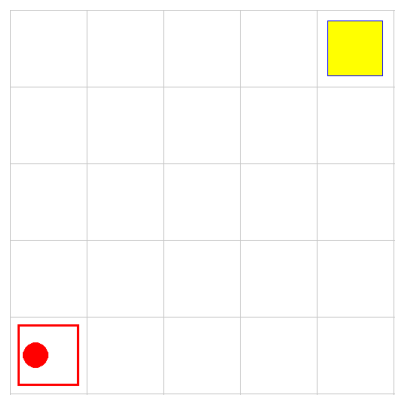

ValueError: too many values to unpack (expected 4)

In [20]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import clear_output

# 1. Initialize with rgb_array for visual frames
if 'env' not in globals():
    env = gym.make(CONFIG.gym_id, render_mode="rgb_array")
    state, _ = env.reset()

# --- HUMAN PLAY ---
# 0=South, 1=North, 2=East, 3=West, 4=Pickup, 5=Dropoff
my_action = 5
# ------------------

# Step the simulation
state, reward, terminated, truncated, _ = env.step(my_action)

# 2. Get the single frame
img = env.render()

# 3. Visualize
clear_output(wait=True)
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis('off')
plt.show()

# Data output
taxi_row, taxi_col, p_loc, dest = env.unwrapped.decode(state)
print(f"Action: {my_action} | Reward: {reward}")
print(f"Row: {taxi_row}, Col: {taxi_col}, P_Loc: {p_loc}, Dest: {dest}")

if terminated or truncated:
    print("Goal reached or Resetting...")
    state, _ = env.reset()